In [35]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

***MICROSOFT CASE***

In [36]:
tickers = "MSFT"
msft = yf.Ticker(tickers)
data = msft.history(start="2023-11-02", end="2024-11-02", interval="1d")
print(data.head())

                                 Open        High         Low       Close  \
Date                                                                        
2023-11-02 00:00:00-04:00  340.668176  342.228080  338.244922  341.727753   
2023-11-03 00:00:00-04:00  343.012967  347.682890  340.756478  346.122955   
2023-11-06 00:00:00-05:00  346.760654  350.773243  346.662540  349.782349   
2023-11-07 00:00:00-05:00  352.598016  355.600100  350.861526  353.706635   
2023-11-08 00:00:00-05:00  354.834859  356.983414  353.726241  356.326111   

                             Volume  Dividends  Stock Splits  
Date                                                          
2023-11-02 00:00:00-04:00  24348100        0.0           0.0  
2023-11-03 00:00:00-04:00  23637700        0.0           0.0  
2023-11-06 00:00:00-05:00  23828300        0.0           0.0  
2023-11-07 00:00:00-05:00  25833900        0.0           0.0  
2023-11-08 00:00:00-05:00  26767800        0.0           0.0  


In [37]:
close_prices = data['Close']
df_close = pd.DataFrame({"Date": close_prices.index, "Close": close_prices.values})
df_close.reset_index(drop=True, inplace=True)
print(df_close.head())

                       Date       Close
0 2023-11-02 00:00:00-04:00  341.727753
1 2023-11-03 00:00:00-04:00  346.122955
2 2023-11-06 00:00:00-05:00  349.782349
3 2023-11-07 00:00:00-05:00  353.706635
4 2023-11-08 00:00:00-05:00  356.326111


In [38]:
df_close.to_csv("/tmp/msft_close_prices.csv", index=False)


In [39]:
df_microsoft = pd.read_csv("/tmp/msft_close_prices.csv")
df_microsoft.head()

,Date,Close
0,2023-11-02 00:00:00-04:00,341.727753
1,2023-11-03 00:00:00-04:00,346.122955
2,2023-11-06 00:00:00-05:00,349.782349
3,2023-11-07 00:00:00-05:00,353.706635
4,2023-11-08 00:00:00-05:00,356.326111


/var/folders/62/rh9l84sx6d70_dkrpcr4kfbr0000gn/T/ipykernel_41058/4204217032.py:1: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df_microsoft['Date'] = pd.to_datetime(df_microsoft['Date'])


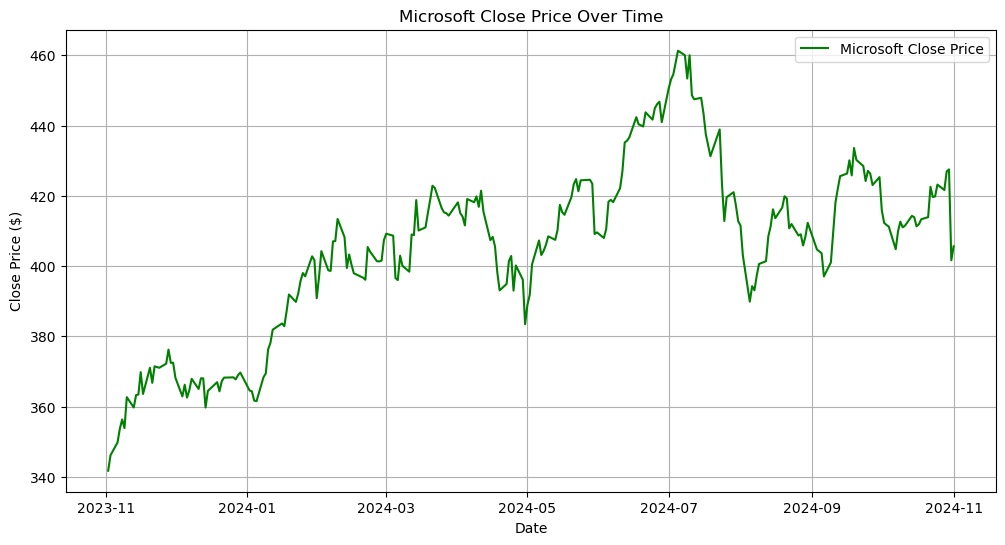

In [40]:
df_microsoft['Date'] = pd.to_datetime(df_microsoft['Date'])
df_microsoft.set_index('Date', inplace=True)
plt.figure(figsize=(12, 6))
plt.plot(df_microsoft.index, df_microsoft['Close'], color ='green', label='Microsoft Close Price')
plt.title('Microsoft Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price ($)')
plt.grid(True)
plt.legend()
plt.show()

***DATA COMPLETETENESS***

In [41]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 252 entries, 2023-11-02 00:00:00-04:00 to 2024-11-01 00:00:00-04:00
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          252 non-null    float64
 1   High          252 non-null    float64
 2   Low           252 non-null    float64
 3   Close         252 non-null    float64
 4   Volume        252 non-null    int64  
 5   Dividends     252 non-null    float64
 6   Stock Splits  252 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 15.8 KB


In [42]:
data.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,252.000000,252.000000,252.000000,252.000000,2.520000e+02,252.000000,252.0
mean,405.163307,408.107972,401.621410,405.060441,2.137963e+07,0.011905,0.0
std,24.711340,24.710355,24.300515,24.408196,8.312233e+06,0.093925,0.0
min,340.668176,342.228080,338.244922,341.727753,9.932800e+06,0.000000,0.0
25%,394.953890,398.664506,391.621598,393.988045,1.625822e+07,0.000000,0.0
50%,409.686602,411.531252,405.037375,408.678528,1.936640e+07,0.000000,0.0
75%,419.541192,422.384174,415.871920,419.672134,2.392882e+07,0.000000,0.0
max,460.770111,462.102101,458.263980,461.322632,7.850230e+07,0.750000,0.0


In [43]:
data.shape

(252, 7)

In [44]:
data.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits'], dtype='object')

In [45]:
print(f"The missing values in the dataset: {data['Close'].isnull().sum()}")

The missing values in the dataset: 0


In [46]:
total_rows = len(data)

missing_info = pd.DataFrame({
    'missing_count': data.isnull().sum(),
    'missing_percentage': (data.isnull().sum() / total_rows) * 100
})

print(missing_info)


              missing_count  missing_percentage
Open                      0                 0.0
High                      0                 0.0
Low                       0                 0.0
Close                     0                 0.0
Volume                    0                 0.0
Dividends                 0                 0.0
Stock Splits              0                 0.0


***DATA LATENCY***

In [47]:
min_close = data['Close'].min()
max_close = data['Close'].max()
print(f"Minimum Close Price: {min_close}")
print(f"Maximum Close Price: {max_close}")
print(f"Difference between Max and Min Close Price: {max_close - min_close}")

Minimum Close Price: 341.7277526855469
Maximum Close Price: 461.3226318359375
Difference between Max and Min Close Price: 119.59487915039062


***DATA CONSISTENCY***

In [48]:
print(data.dtypes)

Open            float64
High            float64
Low             float64
Close           float64
Volume            int64
Dividends       float64
Stock Splits    float64
dtype: object


In [49]:
print(data.apply(lambda x: x.map(type).nunique()))

Open            1
High            1
Low             1
Close           1
Volume          1
Dividends       1
Stock Splits    1
dtype: int64


***ERROR RATE***

In [50]:
missing_rate = data.isnull().mean() * 100
print(missing_rate)

Open            0.0
High            0.0
Low             0.0
Close           0.0
Volume          0.0
Dividends       0.0
Stock Splits    0.0
dtype: float64


In [51]:
duplicate_rate = data.duplicated().mean() * 100
print(duplicate_rate)

0.0


In [52]:
Q1 = data['Close'].quantile(0.25)
Q3 = data['Close'].quantile(0.75)
IQR = Q3 - Q1
outliers = ((data['Close'] < Q1 - 1.5 * IQR) | (data['Close'] > Q3 + 1.5 * IQR)).mean() * 100
print(outliers)

3.1746031746031744


***DATA ACCURACY***

In [53]:
minimum_price = data['Close'].min()
max_price = data['Close'].max()

print("The minimum recorded price is", minimum_price)

print("The maximum recorded price is", max_price)

The minimum recorded price is 341.7277526855469
The maximum recorded price is 461.3226318359375


In [54]:
negative_price_count = (data['Close'] < 0).sum()
print("Number of records with negative Close price:", negative_price_count)

Number of records with negative Close price: 0


In [55]:
valid_close = data['Close'] > 0
valid_volume = data['Volume'] > 0
valid_dividends = data['Dividends'].notnull()

accurate_records = data[valid_close & valid_volume & valid_dividends]
data_accuracy_rate = (len(accurate_records) / len(data)) * 100
print(f"✅ Data Accuracy Rate: {data_accuracy_rate:.2f}%")

✅ Data Accuracy Rate: 100.00%


In [56]:
invalid_records = data[~(valid_close & valid_volume & valid_dividends)]
invalid_value_rate = (len(invalid_records) / len(data)) * 100
print(f"❌ Invalid Value Rate: {invalid_value_rate:.2f}%")


❌ Invalid Value Rate: 0.00%


In [57]:
duplicate_rows = data.duplicated()
duplicate_accuracy_rate = ((~duplicate_rows).sum() / len(data)) * 100
print(f"📄 Duplicate Accuracy Rate: {duplicate_accuracy_rate:.2f}%")

📄 Duplicate Accuracy Rate: 100.00%


In [58]:
unit_price_accuracy = (data['Close'] > 0).sum() / len(data) * 100
print(f"💰 Close Price Field Accuracy Rate: {unit_price_accuracy:.2f}%")

💰 Close Price Field Accuracy Rate: 100.00%
